# Synthetischer Datensatz — Adaption

Adaptiert das in *synthetic_data_model.ipynb* trainierte MLP an den drift-behafteten
Strom mit vier Strategien (Baseline, Passiv, Aktiv, Kombiniert) sowie der passiven
Strategie mit Recurrence-Selektor (`blind_rec`, Masterarbeit Abschn. 5.5.3: Rückholung
vergangener Punkte mit ähnlichem Fehler); Module `drift_adaptation.py` / `drift_detection.py`.

Die Einteilung folgt Gama et al. (2014, Abschn. 3.3.2): *blind* = rein periodisches
Nachtraining ohne Fehlerauswertung, *informed* = trigger-basiert. Als Trigger werden
alle fünf Detektoren gescreent — die vier statistischen Verfahren sowie der
Schwellwert-Detektor `RMSE`, der die Überwachung eines Performance-Indikators
(Gama Abschn. 3.2) in ihrer einfachsten Form darstellt. Die aktive und die
kombinierte Strategie werden anschließend mit dem im Screening besten Detektor
ausgewertet.

In [1]:
FORCE_RECOMPUTE = False   
IS_FINAL = True

In [2]:
# --- Konstanten ---
RUN_ID = "e7f8df2f"   # None -> neuestes Modell

SEED = 42

STEP_S = 600                 # Abtastung des Adaptionsstroms
STEP_TUNE_S = 3600           # groebere Abtastung fuers Tuning
DETECTORS = ("KSWIN", "ADWIN", "DDM", "EDDM", "RMSE")
N_TRIALS = {"screening": 40, "final": 60}
TUNE_WEIGHTS = (1.0, 0.1)
# Refraktaerzeit zwischen zwei Sofort-Trainings (x * T_stat); cooldown wird als cooldown_x in [0, 60] getunt
COOLDOWN_X = 30
# Update-Validierung: Nachtraining verwerfen, wenn der MSE nicht sinkt
REJECT = True

N_SEED_RUNS = 50              # Zielzahl an Laeufen mit identischer Konfiguration

import numpy as np
SCREENING_SEEDS = (SEED, *np.random.default_rng(SEED).integers(1, 2**10 - 1, size=4).tolist())

In [3]:
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, "..", ".."))

base_dir = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir = base_dir / "data" / "synthetic_data"
model_dir = base_dir / "models"
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"

for _d in (data_dir, model_dir, plot_dir, results_dir):
    os.makedirs(_d, exist_ok=True)

## Daten und Basismodell laden

In [4]:
import pandas as pd
from src.utils import run_registry as rr
rr.assert_current()

data_store = rr.synthetic_data_store(data_dir)
model_store = rr.synthetic_model_store(model_dir)

if RUN_ID is None:
    run_id = model_store.latest_id("model")
    if run_id is None:
        raise FileNotFoundError("Kein data-Artefakt. Bitte syn_model.ipynb ausfuehren.")
else:
    run_id = RUN_ID
print(f"model run_id = {run_id}")

rng = np.random.default_rng(SEED)
test_data = data_store.load("data_test", run_id=run_id, rename=True, rekey=True)
test_cfg = rr.RunConfig.from_document(test_data.attrs.get("config", test_data.attrs))

_mc = model_store.load("model", run_id=run_id, rename=True)
base_model = _mc["model"]
X_scaler = _mc["X_scaler"]
y_scaler = _mc["y_scaler"]

ledger = rr.run_ledger(work_dir)
ledger.bind("adaptation", parents={"model": test_cfg.id})
plot_store = rr.synthetic_plot_store(plot_dir, ledger=ledger)
res_store  = rr.synthetic_results_store(results_dir, ledger=ledger)

model run_id = e7f8df2f


I0000 00:00:1790243036.708348       7 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1790243038.970749       7 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


E0000 00:00:1790243041.040014       7 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/opt/venv/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/venv/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
STRIDE = max(1, STEP_S // 60)
stream = test_data.iloc[::STRIDE].copy()
N = len(stream)
print(f"Adaptionsstrom: {N} Punkte (STEP={STEP_S}s, STRIDE={STRIDE})")

X_free = X_scaler.transform(stream[["u1_noise_filt", "u2_noise_filt"]].to_numpy()).astype("float32")
y_free = y_scaler.transform(stream[["y_noise_filt"]].to_numpy()).ravel().astype("float32")

X_cd = X_scaler.transform(stream[["u1_cd_noise_filt", "u2_cd_noise_filt"]].to_numpy()).astype("float32")
y_cd = y_scaler.transform(stream[["y_cd_noise_filt"]].to_numpy()).ravel().astype("float32")

cd_signal = stream["cd"].to_numpy()
time_index = stream.index

Adaptionsstrom: 52560 Punkte (STEP=600s, STRIDE=10)


## Adaptionsstrategien

In [6]:
import tensorflow as tf
import drift_adaptation as da
from drift_adaptation import run_adaptation, StreamingDetector

# Ein laufender Kernel haelt das Modul fest; assert_current bricht ab, wenn die
# Datei inzwischen abweicht. SPACE_ID kommt aus dem GELADENEN Code-Objekt und
# geht in die Cache-Schluessel ein, damit eine geaenderte Grenze in
# _suggest_adapt_params den Cache verwirft statt ihn stillschweigend zu treffen.
da.assert_current()
SPACE_ID = da.adapt_space_id()
print(f"Suchraum-Kennung: {SPACE_ID}")

Suchraum-Kennung: c3683005


## Detektor-Konfiguration (für die Informed-Adaption)

Die Detektorparameter werden **nicht** aus *syn_detection* übernommen, sondern im geschlossenen Regelkreis mitgetunt (`_suggest_adapt_params` in `drift_adaptation.py`): das Fehlerniveau nach einem Nachtraining unterscheidet sich vom statischen Fehlerstrom des Detektions-Notebooks, dort kalibrierte Werte sind hier systematisch fehlangepasst.

`make_detector` liefert deshalb nur die Hülle; `apply_det_params` setzt vor jedem Trial und jedem Lauf die getunten Werte. Ein Warmstart aus `syn_detection.json` wäre zudem in zweifacher Hinsicht unbrauchbar: er überträgt Schrittzahlen von einem 60-s-Strom auf das `STEP_TUNE_S`-Raster, und für DDM und EDDM läge sein `err_threshold` außerhalb des hier gesuchten Bereichs — Optuna benutzt einen solchen Wert unverändert weiter, statt ihn zu begrenzen, und verzerrt damit die erste Beobachtung.

In [7]:
import json   # fuer das Scannen des Seed-Archivs weiter unten


def make_detector(name):
    """Frischer StreamingDetector aus den Modul-Defaults von drift_detection.py.

    Konstruktionswerte bleiben ohne Wirkung: apply_det_params ueberschreibt vor
    jedem Lauf saemtliche Detektorparameter mit den im Adaptions-Tuning
    optimierten (s. Markdown darueber).
    """
    return StreamingDetector(name)


def detector_factory(name):
    return lambda: make_detector(name)

In [8]:
_base_free_pred = base_model.predict(X_free, verbose=0).ravel()
_base_free_err = y_free - _base_free_pred
NORM_MEAN = float(np.mean(_base_free_err))
NORM_STD = float(np.std(_base_free_err)) or 1.0
print(f"Normierungs-Baseline: mean={NORM_MEAN:.4g}, std={NORM_STD:.4g}")

Normierungs-Baseline: mean=-0.0009897, std=0.008199


## Hyperparameter-Tuning der Adaption

In [9]:
STRIDE_TUNE = max(1, STEP_TUNE_S // 60)

_tune = test_data.iloc[::STRIDE_TUNE]
X_tune = X_scaler.transform(_tune[["u1_cd_noise_filt", "u2_cd_noise_filt"]].to_numpy()).astype("float32")
y_tune = y_scaler.transform(_tune[["y_cd_noise_filt"]].to_numpy()).ravel().astype("float32")

_, T_STAT_TUNE = da.estimate_cooldown(_tune[["w1", "w2"]], x=COOLDOWN_X)

# Ein Chunk entspricht einem Tag, damit Tuning- und Zielaufloesung auf dieselbe
# Zahl an Adaptionsschritten kommen. Die fruehere Untergrenze von 24 Punkten
# hielt den Tagesbezug nur, solange die Tuningabtastung feiner als ein Tag ist.
# Im TEP ergibt 86400 // 10800 nur acht, die Klemme machte den Tuning-Chunk
# dadurch 72 statt 24 Stunden lang und das Tuning lief auf einem Drittel der
# Schritte der Zielaufloesung -- im synthetischen Fall griff sie gerade nicht.
CHUNK_TUNE = max(1, 86400 // STEP_TUNE_S)
TUNE_FIXED = dict(chunk=CHUNK_TUNE, reject=REJECT,
                  norm_mean=NORM_MEAN, norm_std=NORM_STD, seed=SEED)

best_adapt_params, studies, tune_cfgs = {}, {}, {}

def _tune_case(key, strategy, n_trials, det_name=None, enqueue=None, extra_cfg=None):
    """Tunt einen Fall und cached ihn ueber die RunConfig-Kennung."""
    tune_params = {"method": strategy, "case": key, "n_trials": n_trials,
                   "weights": list(TUNE_WEIGHTS), "step_tune_s": STEP_TUNE_S,
                   "step_s": STEP_S, "space": SPACE_ID,
                   "scheme": "phase-extend", "cooldown_tuned": True,
                   **({"detector": det_name} if det_name else {}),
                   **(extra_cfg or {}),
                   **{k: TUNE_FIXED[k] for k in sorted(TUNE_FIXED)
                      if not k.startswith("norm_")}}
    tune_cfgs[key] = test_cfg.compose(tuning=tune_params)
    # Ohne rekey: aeltere Artefakte tragen weniger Schluessel und sind damit
    # Teil-Dokumente der heutigen Konfiguration. Der Superset-Fallback wuerde
    # ein Tuning von damals uebernehmen, statt neu zu rechnen. Der Cache muss
    # deshalb exakt getroffen werden.
    if (model_store.exists("adapt_tuning", tune_cfgs[key])
            and not FORCE_RECOMPUTE):
        best_adapt_params[key] = model_store.load("adapt_tuning", tune_cfgs[key])
        print(f"{key:18s} aus Cache")
        return
    tf.keras.utils.set_random_seed(SEED)
    _fac = detector_factory(det_name) if det_name else None
    _study, _ = da.tune_adaptation(strategy, base_model, X_tune, y_tune,
                                   fixed=TUNE_FIXED, detector_factory=_fac,
                                   n_trials=n_trials, weights=TUNE_WEIGHTS,
                                   seed=SEED, enqueue=enqueue, t_stat=T_STAT_TUNE)
    studies[key] = _study
    best_adapt_params[key] = da.decode_adapt_params(_study.best_params)
    _a = _study.best_trial.user_attrs
    print(f"{key:18s} score={_study.best_value:.3f} | rmse={_a['rmse']:.3f} "
          f"n_train={_a['n_train']:3d} n_detect={_a['n_detect']:3d}")
    model_store.save(best_adapt_params[key], "adapt_tuning", tune_cfgs[key])

# --- Passive Strategie (detektorfrei, finale Konfiguration direkt) ---
_tune_case("blind", "blind", N_TRIALS["final"])
# Recurrence-Selektor auf der passiven Strategie; das blind-Optimum wird als
# Teilkandidat eingereiht (fehlende Selektorparameter zieht Optuna selbst).
_tune_case("blind_rec", "blind_rec", N_TRIALS["final"],
           enqueue=[da.encode_adapt_params(best_adapt_params["blind"])])

# --- Screening: informierte Strategie je Detektor, reduziertes Budget ---
# Ohne Warmstart: jeder Detektor startet unter denselben Bedingungen, sonst
# waere der Vergleich, aus dem BEST_DETECTOR folgt, nicht fair.
print(f"\nDetektor-Screening ({N_TRIALS['screening']} Trials je Detektor)")
for _det in DETECTORS:
    _tune_case(f"informed@{_det}", "informed", N_TRIALS["screening"], det_name=_det)

blind              aus Cache
blind_rec          aus Cache

Detektor-Screening (40 Trials je Detektor)
informed@KSWIN     aus Cache
informed@ADWIN     aus Cache
informed@DDM       aus Cache
informed@EDDM      aus Cache
informed@RMSE      aus Cache


In [10]:
from scipy import stats

# Gegenpruefung des Screenings auf dem voll aufgeloesten Strom. Ausgewaehlt wird
# der Detektor mit dem kleinsten mittleren RMSE ueber SCREENING_SEEDS; das
# Tuning laeuft auf einem groeber abgetasteten Strom, die Uebertragung der
# Konfiguration ist daher eine Extrapolation und muss geprueft werden. Ein
# einzelner Seed reicht dafuer nicht: die Abstaende zwischen den Detektoren
# sind kleiner als die Seed-Streuung derselben Strategie (informed mit DDM
# +/- 0,15 bei 11 Seeds, Screening-Abstand DDM/RMSE 0,01).
_RESCALE = STRIDE_TUNE / STRIDE
CHUNK = max(24, 86400 // STEP_S)
_BASE_CFG = dict(chunk=CHUNK, reject=REJECT, norm_mean=NORM_MEAN, norm_std=NORM_STD)
COOLDOWN, T_stat = da.estimate_cooldown(stream[["w1", "w2"]], x=COOLDOWN_X)

_scr_cfg = test_cfg.compose(screening={
    "detectors": sorted(DETECTORS), "step_s": STEP_S, "cooldown_x": COOLDOWN_X,
    "space": SPACE_ID,
    "rescale": _RESCALE, "reject": REJECT,
    "seeds": [int(s) for s in SCREENING_SEEDS],
    "params": {d: da.encode_adapt_params(best_adapt_params[f"informed@{d}"])
               for d in DETECTORS}})

# Ohne rekey, aus demselben Grund wie beim Tuning: aeltere Eintraege kennen
# weder "space" noch "seeds" und wuerden als Teil-Dokument uebernommen --
# samt eines screening-Dicts ohne rmse_seeds.
if model_store.exists("adapt_screening", _scr_cfg) and not FORCE_RECOMPUTE:
    screening = model_store.load("adapt_screening", _scr_cfg)
    print("Screening aus Cache")
else:
    screening = {}
    for _det in DETECTORS:
        _key = f"informed@{_det}"
        _rmse, _ntr = [], []
        for _sd in SCREENING_SEEDS:
            _, _tab = da.crosscheck_candidates(
                base_model, X_cd, y_cd,
                best_params={"informed": best_adapt_params[_key]}, fixed=_BASE_CFG,
                t_stat=T_stat, detector_factory=detector_factory(_det),
                study=None, top_k=0, rescale=_RESCALE, mode="informed", seed=int(_sd),
                verbose=False)
            _rmse.append(float(_tab["tpe_best"]["rmse"]))
            _ntr.append(int(_tab["tpe_best"]["n_train"]))
        screening[_det] = {"rmse": float(np.mean(_rmse)), "rmse_std": float(np.std(_rmse, ddof=1)),
                           "rmse_seeds": _rmse, "n_train": float(np.mean(_ntr))}
        print(f"{_det:6s} RMSE={screening[_det]['rmse']:.4f} "
              f"+/- {screening[_det]['rmse_std']:.4f}  "
              f"({', '.join(f'{r:.3f}' for r in _rmse)})  "
              f"n_train={screening[_det]['n_train']:.0f}")

    model_store.save(screening, "adapt_screening", _scr_cfg)

# Rangfolge bei Gleichstand: Verfahren mit den wenigsten Annahmen zuerst
# (Schwelle auf dem Indikator -> fehlerratenbasiert -> fensterbasierte Tests).
TIE_ORDER = ("RMSE", "DDM", "EDDM", "ADWIN", "KSWIN")
TIE_ALPHA = 0.05
# Zweite Bedingung neben dem p-Wert: der Kandidat darf hoechstens TIE_MAX_REL
# ueber dem kleinsten mittleren RMSE liegen. Bei fuenf Seeds kann der gepaarte
# Test gegen einen Kandidaten mit grosser Streuung nicht trennen und bescheinigt
# dann Gleichwertigkeit aus fehlender Trennschaerfe statt aus Naehe -- im TEP
# wurde so ein Detektor mit dem sechsfachen mittleren Fehler und einer Streuung
# groesser als sein eigener Mittelwert gewaehlt. Ein echter Gleichstand liegt
# weit unter der Schranke (im synthetischen Fall trennen die beiden Besten
# wenige Promille), die Schranke aendert dort also nichts.
TIE_MAX_REL = 0.05

_lead = min(screening, key=lambda d: screening[d]["rmse"])
_tied = []
for _det in DETECTORS:
    if _det == _lead:
        _tied.append(_det); continue
    _p = stats.ttest_rel(screening[_det]["rmse_seeds"], screening[_lead]["rmse_seeds"]).pvalue
    _rel = screening[_det]["rmse"] / (screening[_lead]["rmse"] or np.nan) - 1.0
    screening[_det]["p_vs_lead"] = float(_p)
    screening[_det]["rel_vs_lead"] = float(_rel)
    if _p > TIE_ALPHA and _rel <= TIE_MAX_REL:
        _tied.append(_det)
screening[_lead]["p_vs_lead"] = 1.0
screening[_lead]["rel_vs_lead"] = 0.0
BEST_DETECTOR = min(_tied, key=TIE_ORDER.index)
SCREEN_LEAD = _lead          # kleinster mittlerer RMSE
SCREEN_TIED = tuple(_tied)   # davon statistisch nicht zu unterscheiden

print(f"\nKleinster RMSE: {_lead}; gleichwertig (p > {TIE_ALPHA} und "
      f"hoechstens {100 * TIE_MAX_REL:.0f} % darueber): {_tied}")
print(f"Gewaehlter Detektor: {BEST_DETECTOR} "
      f"(RMSE={screening[BEST_DETECTOR]['rmse']:.4f} "
      f"+/- {screening[BEST_DETECTOR]['rmse_std']:.4f} ueber {len(SCREENING_SEEDS)} Seeds)")

screening_table = pd.DataFrame(
    {d: {"rmse": v["rmse"], "rmse_std": v["rmse_std"], "p_vs_lead": v["p_vs_lead"],
         "rel_vs_lead": v["rel_vs_lead"], "n_train": v["n_train"]}
     for d, v in screening.items()}).T

Screening aus Cache

Kleinster RMSE: RMSE; gleichwertig (p > 0.05 und hoechstens 5 % darueber): ['RMSE']
Gewaehlter Detektor: RMSE (RMSE=0.5934 +/- 0.0033 ueber 5 Seeds)


In [11]:
# Der gewaehlte Detektor wird mit vollem Budget nachgetunt (Warmstart mit dem
# Screening-Optimum), danach die kombinierte Strategie mit demselben Detektor
# (Warmstart mit der Vereinigung der Einzeloptima).
_scr = best_adapt_params[f"informed@{BEST_DETECTOR}"]
_tune_case("informed", "informed", N_TRIALS["final"], det_name=BEST_DETECTOR,
           enqueue=[da.encode_adapt_params(_scr)])

_bl, _inf = best_adapt_params["blind"], best_adapt_params["informed"]
_tune_case("combined", "combined", N_TRIALS["final"], det_name=BEST_DETECTOR,
           enqueue=[da.encode_adapt_params({**_bl, **_inf}),
                    da.encode_adapt_params({**_inf, **_bl})])

# --- Gegenpruefung auf voller Aufloesung -------------------------------------
# Eigener Cache-Fall: der Crosscheck darf NICHT nach "adapt_tuning" zurueck-
# schreiben, sonst laedt _tune_case beim naechsten Lauf sein eigenes Ergebnis
# und die Gegenpruefung startet von einem anderen Kandidatensatz.
# Der Schluessel haengt an den TPE-Optima (= Eingang), damit er inhalts-
# adressiert und ueber Laeufe hinweg stabil ist.
_CC_KEYS = ("blind", "informed", "combined", "blind_rec")
_cc_cfg = test_cfg.compose(crosscheck={
    "detector": BEST_DETECTOR,
    "space": SPACE_ID,
    "step_s": STEP_S,
    "cooldown_x": COOLDOWN_X,
    "rescale": float(_RESCALE),
    "reject": REJECT,
    "chunk": CHUNK,
    "top_k": 3,
    # Die Gegenpruefung entscheidet ueber mehrere Seeds und nach der
    # Gleichstandsregel. Beides gehoert in die Kennung, denn es ist eine andere
    # Entscheidung als der kleinste RMSE auf einem Seed.
    "seeds": [int(s) for s in SCREENING_SEEDS],
    "tie_alpha": TIE_ALPHA,
    "tie_max_rel": TIE_MAX_REL,
    "tpe": {k: da.encode_adapt_params(best_adapt_params[k]) for k in _CC_KEYS},
})

# Ohne rekey: ein hinzugekommener Schluessel ist formal eine Ergaenzung,
# inhaltlich aber ein anderer Kandidatensatz. Der Superset-Fallback wuerde
# sonst ein Ergebnis zu anderen Kandidaten still uebernehmen.
if model_store.exists("adapt_crosscheck", _cc_cfg) and not FORCE_RECOMPUTE:
    best_adapt_params.update(model_store.load("adapt_crosscheck", _cc_cfg))
    print(f"Crosscheck aus Cache ({BEST_DETECTOR})")
    for _m in _CC_KEYS:
        print(f"  {_m:9s} {best_adapt_params[_m]}")
else:
    # informed zuerst, da der union-Kandidat der kombinierten Strategie dessen
    # Optimum nutzt.
    _extra = {"informed": {"combined_cfg": dict(best_adapt_params["combined"]),
                           "screening_cfg": dict(_scr)}}
    for _m in ("informed", "combined"):
        print(f"--- {_m} ({BEST_DETECTOR}) ---")
        best_adapt_params[_m], _ = da.crosscheck_candidates(
            base_model, X_cd, y_cd, best_params=best_adapt_params, fixed=_BASE_CFG,
            t_stat=T_stat, detector_factory=detector_factory(BEST_DETECTOR),
            study=studies.get(_m), rescale=_RESCALE, mode=_m, seed=SEED,
            seeds=SCREENING_SEEDS, tie_alpha=TIE_ALPHA, tie_max_rel=TIE_MAX_REL,
            extra=_extra.get(_m))

    # Die passive Strategie ebenfalls gegenpruefen (blind_period wird mitskaliert)
    print("--- blind ---")
    best_adapt_params["blind"], _ = da.crosscheck_candidates(
        base_model, X_cd, y_cd, best_params=best_adapt_params, fixed=_BASE_CFG,
        t_stat=T_stat, detector_factory=None, study=studies.get("blind"),
        rescale=_RESCALE, mode="blind", seed=SEED, seeds=SCREENING_SEEDS,
        tie_alpha=TIE_ALPHA, tie_max_rel=TIE_MAX_REL)
    print("--- blind_rec ---")
    best_adapt_params["blind_rec"], _ = da.crosscheck_candidates(
        base_model, X_cd, y_cd, best_params=best_adapt_params, fixed=_BASE_CFG,
        t_stat=T_stat, detector_factory=None, study=studies.get("blind_rec"),
        rescale=_RESCALE, mode="blind_rec", seed=SEED, seeds=SCREENING_SEEDS,
        tie_alpha=TIE_ALPHA, tie_max_rel=TIE_MAX_REL)

    model_store.save({k: best_adapt_params[k] for k in _CC_KEYS},
                     "adapt_crosscheck", _cc_cfg)

informed           aus Cache
combined           aus Cache
Crosscheck aus Cache (RMSE)
  blind     {'lr': 0.006975594220633555, 'epochs': 18, 'freeze': (False, False, False), 'reset': False, 'blind_window': 234, 'blind_period': 72}
  informed  {'lr': 0.0010417304906269096, 'epochs': 18, 'freeze': (False, False, False), 'reset': False, 'window_prev': 234, 'window_post': 7, 'cooldown_x': 4.511730040081524, 'det_window': 60, 'det_threshold': 2.651518921482102}
  combined  {'lr': 0.0010417304906269096, 'epochs': 18, 'freeze': (False, False, False), 'reset': False, 'blind_window': 234, 'blind_period': 72, 'window_prev': 234, 'window_post': 7, 'cooldown_x': 4.511730040081524, 'det_window': 60, 'det_threshold': 2.651518921482102}
  blind_rec {'lr': 0.002132942698873188, 'epochs': 24, 'freeze': (True, False, False), 'reset': False, 'blind_window': 373, 'blind_period': 72, 'err_tol': 0.5468100893726192, 'rec_horizon': 4424, 'rec_max': 320}


## Adaption ausführen

In [12]:
ADAPT_CFG = dict(
    lr=3e-3, epochs=9, freeze=(True, False, False), reset=False,
    blind_window=44, blind_period=CHUNK,        # Default: taegliches Nachtraining
    window_prev=max(1, 300 // STRIDE), window_post=max(1, 300 // STRIDE),
    reject=REJECT, chunk=CHUNK, norm_mean=NORM_MEAN, norm_std=NORM_STD,
)
STRATEGIES = ("baseline", "blind", "blind_chunk", "informed", "combined", "blind_rec")

# run_adaptation kennt nur die Grundmodi baseline/blind/informed/combined (plus
# Suffix _rec). Zusammengesetzte Namen der Auswertung werden hier abgebildet.
MODE_OF = {"blind_chunk": "blind"}

# blind_chunk = dieselbe getunte Konfiguration wie blind, aber mit Nachtraining
# in JEDEM Chunk auf dem Chunk selbst. Der Vergleich beider Zeilen isoliert
# damit allein die Eingriffsfrequenz, alles uebrige ist identisch. Die Werte
# stehen in Tuningaufloesung, scale_adapt_params rechnet sie unten um.
_EQ_CHUNK = max(1, round(CHUNK / _RESCALE))
best_adapt_params["blind_chunk"] = {**best_adapt_params["blind"],
                                    "blind_window": _EQ_CHUNK,
                                    "blind_period": _EQ_CHUNK}

# cooldown_x -> cooldown (Vielfaches der stationaeren Phasendauer der Zielaufloesung);
# fuer baseline/blind ohne Wirkung (kein cooldown_x im Parametersatz).
applied_cfg = {s: da.resolve_cooldown(
                   {**ADAPT_CFG, **da.scale_adapt_params(best_adapt_params.get(s, {}), _RESCALE)},
                   T_stat)
               for s in STRATEGIES}
print(f"T_stat ~ {T_stat:.0f} Punkte (~{T_stat * STEP_S / 3600:.1f} h) | "
      f"Detektor = {BEST_DETECTOR} | cooldown je Strategie getunt")

adapt_cfg = test_cfg.compose(adaptation={
    "step_s": STEP_S, "detector": BEST_DETECTOR, "scheme": "phase-extend",
    "cooldown_tuned": True, "screening": sorted(DETECTORS),
    "applied": {k: {kk: v for kk, v in applied_cfg[k].items()
                    if kk not in ("norm_mean", "norm_std")} for k in STRATEGIES}})

# rekey ist hier bewusst aus: der Superset-Fallback von ArtifactStore.resolve
# uebernimmt einen vorhandenen Eintrag, dessen Konfiguration in der neuen nur
# ergaenzt wird. Eine zusaetzliche Strategie in "applied" ist formal genau das,
# inhaltlich aber nicht -- der uebernommene Lauf haette eine Strategie zu wenig.
# Der Waechter darunter faengt denselben Fall fuer Eintraege ab, die bereits
# unter der richtigen Kennung liegen (ein frueherer rekey legte sie dort ab).
_adapt_from_cache = model_store.exists("adaptation", adapt_cfg) and not FORCE_RECOMPUTE
if _adapt_from_cache:
    results = model_store.load("adaptation", adapt_cfg, rename=True)
    _missing = [s for s in STRATEGIES if s not in results]
    if _missing:
        print(f"Cache-Eintrag ohne Strategien {_missing} -- wird neu gerechnet.")
        _adapt_from_cache = False
if not _adapt_from_cache:
    results = {}
    for _name in STRATEGIES:
        tf.keras.utils.set_random_seed(SEED)
        _detector = make_detector(BEST_DETECTOR) if _name in ("informed", "combined") else None
        _detector, _cfg = da.apply_det_params(_detector, applied_cfg[_name])
        print(f"Strategie '{_name}' ...")
        results[_name] = run_adaptation(base_model, X_cd, y_cd,
                                        mode=MODE_OF.get(_name, _name),
                                        detector=_detector, seed=SEED, verbose=True, **_cfg)
        print(f"  -> {len(results[_name]['train_steps'])} Nachtrainings, "
              f"{len(results[_name]['detect_steps'])} Detektionen")
    model_store.save(results, "adaptation", adapt_cfg)

T_stat ~ 43 Punkte (~7.1 h) | Detektor = RMSE | cooldown je Strategie getunt


## Seed-Robustheit — Läufe und repräsentativer Seed

Alle Strategien über `N_SEED_RUNS` Seeds. Der Medoid-Seed (dem Mittel über alle Seeds am nächsten) liefert die exemplarische Zeitreihe weiter unten.

In [13]:
from glob import glob as _glob

_case = "adaptation_seeds"

# 1) Archiv durchsuchen: Laeufe mit derselben Konfiguration, aber anderem Seed
#    (Vergleich ueber die RunConfig-Kennung ohne seed_eval-Sektion)
seed_results = {SEED: results}   # Haupt-Seed aus der Adaptions-Zelle
for _sc_path in sorted(_glob(os.path.join(model_dir, f"{model_store.prefix}_{_case}_*.json"))):
    with open(_sc_path, encoding="utf-8") as _f:
        _sc = json.load(_f)
    if _sc.get("case") != _case:
        continue
    _doc = dict(_sc["config"])
    _seed_sec = _doc.pop("seed_eval", None) or {}
    _seed = _seed_sec.get("seed")
    if _seed is None or _seed in seed_results:
        continue
    if rr.RunConfig.from_document(_doc).id != adapt_cfg.id:
        continue   # andere Adaptions-Konfiguration
    seed_results[_seed] = model_store.load(_case, run_id=_sc["id"], rename=True)
    print(f"Seed {_seed}: aus Archiv geladen")

# 2) Fehlende Laeufe auffuellen. Die Zielliste steht vollstaendig fest, bevor
#    gerechnet wird, und wird nicht mehr waehrend des Auffuellens gezogen.
#    Bisher uebersprang das Ziehen bereits vorhandene Seeds und die Folge hing
#    damit davon ab, was im Archiv lag. Jetzt bestimmen allein SEED und
#    N_SEED_RUNS die Liste.
_rng_seed = np.random.default_rng(SEED)
TARGET_SEEDS = [SEED]
while len(TARGET_SEEDS) < N_SEED_RUNS:
    _s = int(_rng_seed.integers(1, 2**10 - 1))
    if _s not in TARGET_SEEDS:
        TARGET_SEEDS.append(_s)
_todo = [s for s in TARGET_SEEDS if s not in seed_results]
_seeds_added = False
for _seed in _todo:
    _cfg_seed = adapt_cfg.compose(seed_eval={"seed": _seed})
    _res = {}
    for _name in STRATEGIES:
        tf.keras.utils.set_random_seed(_seed)
        _det = make_detector(BEST_DETECTOR) if _name in ("informed", "combined") else None
        _det, _cfg = da.apply_det_params(_det, applied_cfg[_name])
        print(f"Seed {_seed}, Strategie '{_name}' ...")
        _res[_name] = run_adaptation(base_model, X_cd, y_cd,
                                     mode=MODE_OF.get(_name, _name),
                                     detector=_det, seed=_seed, **_cfg)
    model_store.save(_res, _case, _cfg_seed)
    seed_results[_seed] = _res
    _seeds_added = True

# 3) Kombinierte Auswertung ueber alle Seeds
SEEDS = tuple(seed_results)
seed_rmse = pd.DataFrame(
    {_sd: {s: float(np.sqrt(np.mean(np.asarray(_r[s]["errors"], float) ** 2)))
           for s in STRATEGIES}
     for _sd, _r in seed_results.items()})
seed_rmse["mean"] = seed_rmse[list(seed_results)].mean(axis=1)
seed_rmse["std"] = seed_rmse[list(seed_results)].std(axis=1)
print(f"\n{len(seed_results)} Laeufe (Seeds: {list(seed_results)})")
print(seed_rmse.to_string(float_format=lambda v: f"{v:.3f}"))

Seed 66: aus Archiv geladen
Seed 998: aus Archiv geladen
Seed 778: aus Archiv geladen
Seed 799: aus Archiv geladen


Seed 908: aus Archiv geladen
Seed 187: aus Archiv geladen
Seed 539: aus Archiv geladen
Seed 88: aus Archiv geladen
Seed 283: aus Archiv geladen
Seed 95: aus Archiv geladen


Seed 512: aus Archiv geladen
Seed 804: aus Archiv geladen
Seed 775: aus Archiv geladen
Seed 716: aus Archiv geladen
Seed 456: aus Archiv geladen
Seed 791: aus Archiv geladen
Seed 796: aus Archiv geladen
Seed 841: aus Archiv geladen
Seed 646: aus Archiv geladen
Seed 461: aus Archiv geladen
Seed 669: aus Archiv geladen
Seed 70: aus Archiv geladen
Seed 131: aus Archiv geladen
Seed 713: aus Archiv geladen
Seed 412: aus Archiv geladen


Seed 558: aus Archiv geladen
Seed 169: aus Archiv geladen
Seed 948: aus Archiv geladen
Seed 449: aus Archiv geladen
Seed 752: aus Archiv geladen
Seed 734: aus Archiv geladen
Seed 659: aus Archiv geladen
Seed 233: aus Archiv geladen
Seed 92: aus Archiv geladen
Seed 454: aus Archiv geladen
Seed 878: aus Archiv geladen
Seed 777: aus Archiv geladen
Seed 993: aus Archiv geladen
Seed 859: aus Archiv geladen
Seed 567: aus Archiv geladen
Seed 846: aus Archiv geladen
Seed 913: aus Archiv geladen
Seed 443: aus Archiv geladen
Seed 206: aus Archiv geladen
Seed 379: aus Archiv geladen
Seed 525: aus Archiv geladen


Seed 693: aus Archiv geladen
Seed 97: aus Archiv geladen
Seed 363: aus Archiv geladen



50 Laeufe (Seeds: [42, 66, 998, 778, 799, 908, 187, 539, 88, 283, 95, 512, 804, 775, 716, 456, 791, 796, 841, 646, 461, 669, 70, 131, 713, 412, 558, 169, 948, 449, 752, 734, 659, 233, 92, 454, 878, 777, 993, 859, 567, 846, 913, 443, 206, 379, 525, 693, 97, 363])
               42    66   998   778   799   908   187   539    88   283    95   512   804   775   716   456   791   796   841   646   461   669    70   131   713   412   558   169   948   449   752   734   659   233    92   454   878   777   993   859   567   846   913   443   206   379   525   693    97   363  mean   std
baseline    1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 1.663 0.000
blind       0.635 0.655 0.674 0.689 0.661 0.644 0.696 0.633 0.661 0.653 0.659 0.656 0.65

In [14]:
# Repraesentativer Seed fuer die illustrative Zeitreihe weiter unten.
# Medoid = Seed, dessen RMSE-Vektor ueber alle Strategien dem Mittel ueber alle
# Seeds am naechsten liegt (pro Strategie standardisiert). Bewusst DEFINIERT statt
# fix SEED=42, damit die eingebundene Grafik den Gesamttrend repraesentiert.
_seed_cols = list(seed_results)
_M = seed_rmse.loc[list(STRATEGIES), _seed_cols]
_z = _M.sub(_M.mean(axis=1), axis=0).div(_M.std(axis=1).replace(0, 1), axis=0)
_medoid = (_z ** 2).sum(axis=0).pow(0.5).idxmin()
print(f"Repraesentativer (Medoid-)Seed: {_medoid}  (von {len(_seed_cols)} Seeds)")


Repraesentativer (Medoid-)Seed: 804  (von 50 Seeds)


## Vergleich der Adaptionsstrategien

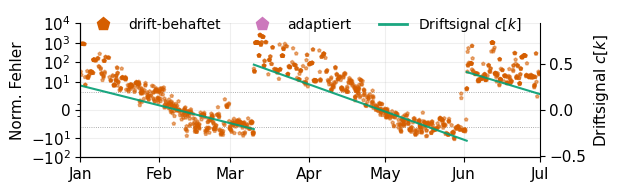

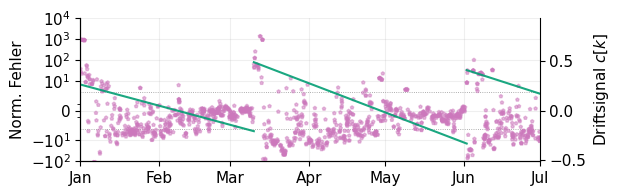

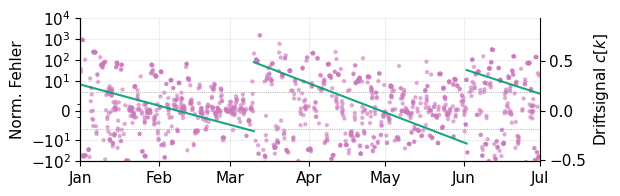

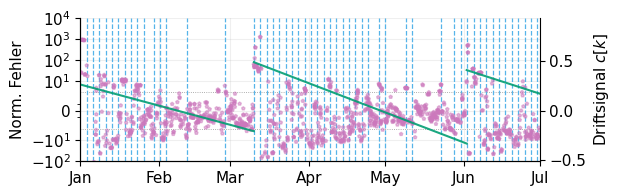

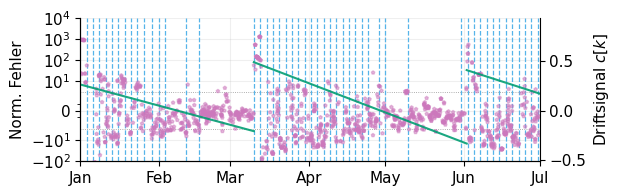

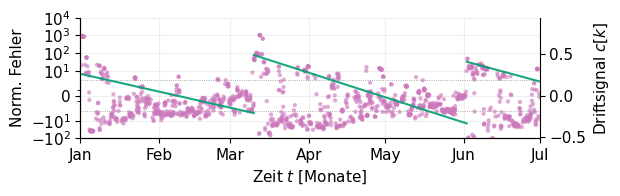

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

PLOT_END = pd.Timestamp("1970-07-01")
_mask_plot = time_index <= PLOT_END
t_plot = time_index[_mask_plot]
cd_plot = cd_signal[_mask_plot]
n_plot = len(t_plot)
cut = np.flatnonzero(np.diff(cd_plot) > 0) + 1   # noch fuer den RMSE-Verlauf unten

PANELS = [("baseline", "Baseline"), ("blind", "Blind"),
          ("blind_chunk", "Blind/Chunk"), ("informed", "Informed"),
          ("combined", "Combined"), ("blind_rec", "Blind+Rec")]

for k, (key, title) in enumerate(PANELS):
    res = seed_results[_medoid][key]
    role = "drift_afflicted" if key == "baseline" else "adapted"
    label = "drift-behaftet" if key == "baseline" else "adaptiert"

    fig, ax, ax2 = ts.error_timeseries(
        t_plot,
        [(res["errors_norm"][_mask_plot], role, label)],
        cd=cd_plot,
        detections=[t_plot[d] for d in res["detect_steps"] if d < n_plot],
        xlabel="Zeit $t$ [Monate]" if k == len(PANELS) - 1 else None,
        ylim=(-1e2, 1e4), frac=0.05, rng=rng,
        legend_series=[("drift_afflicted", "drift-behaftet"), ("adapted", "adaptiert")],
        legend=dict(bbox_to_anchor=[0.49, 1.15], loc="upper center", ncols=3) if k == 0 else False,
    )
    fig.tight_layout()
    if IS_FINAL:
        plot_store.save_figure(fig, f"adaptation_{key}", adapt_cfg,
                               final=IS_FINAL, savefig_kwargs={"dpi": 300},
                               archive_kwargs={"dpi": 300})
    plt.show()


## RMSE-Verlauf der Strategien

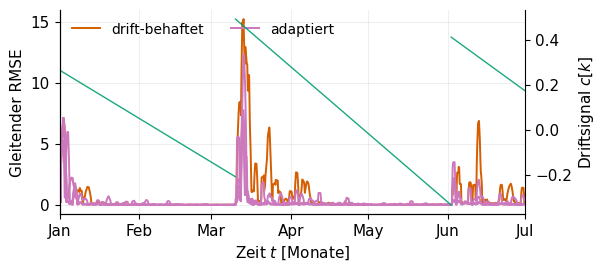

In [16]:
from matplotlib import dates as mdates
from src.utils import thesis_style as ts

WIN = max(10, 86400 // STEP_S)

fig, ax = plt.subplots(figsize=(ts.fig_width(), ts.fig_width(0.45)))

_adapt_labeled = False
for key, title in PANELS:
    e = pd.Series(seed_results[_medoid][key]["errors"], index=time_index)
    rmse_roll = np.sqrt((e ** 2).rolling(WIN, min_periods=1).mean())
    rmse_roll = rmse_roll[rmse_roll.index <= PLOT_END]
    if key == "baseline":
        _col, _lab = ts.C["drift_afflicted"], "drift-behaftet"
    else:
        _col = ts.C["adapted"]
        _lab = "adaptiert" if not _adapt_labeled else None
        _adapt_labeled = True
    ax.plot(rmse_roll.index, rmse_roll.values, color=_col, linewidth=1.4, label=_lab)

ax2 = ax.twinx()
for i, (a, b) in enumerate(zip(np.r_[0, cut], np.r_[cut, len(cd_plot)])):
    ax2.plot(t_plot[a:b], cd_plot[a:b], **ts.line("drift_signal", linewidth=1.0))
ax2.set_ylabel("Driftsignal $c[k]$")
ax2.spines["right"].set_visible(True)
ax2.spines["top"].set_visible(False)

ax.set_ylabel("Gleitender RMSE")
ax.set_xlabel("Zeit $t$ [Monate]")
ax.margins(x=0)
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper left", ncol=2, frameon=False)
fig.tight_layout()
plt.show()

## Numerische Auswertung

In [17]:
def _strategy_stats(res, c, rmse_baseline):
    e = np.asarray(res["errors"], float)
    c = np.asarray(c, float)
    rmse = float(np.sqrt(np.mean(e ** 2)))
    return dict(
        rmse=rmse,
        bias=float(np.mean(e)),
        sigma=float(np.std(e)),
        corr_abs=float(np.corrcoef(np.abs(e), np.abs(c))[0, 1]),
        n_train=int(len(res["train_steps"])),
        n_detect=int(len(res["detect_steps"])),
        n_reject=int(len(res.get("reject_steps", []))),
        n_recall=float(np.mean(res.get("recall_counts") or [0.0])),
        rmse_improvement=float(1.0 - rmse / rmse_baseline) if rmse_baseline else 0.0,
    )

# Kennzahlen ueber ALLE Seeds (Zelle 19) statt nur des Haupt-Seeds. Je Seed die
# Strategie-Statistik berechnen (RMSE-Verbesserung seed-intern gegen die eigene
# Baseline) und anschliessend zu Mittelwert und Streuung ueber die Seeds aggregieren.
_METRIC_COLS = ["rmse", "bias", "sigma", "corr_abs",
                "n_train", "n_detect", "n_reject", "n_recall", "rmse_improvement"]
_rows = [k for k, _ in PANELS]

_per_seed = {}
for _sd, _r in seed_results.items():
    _rb = float(np.sqrt(np.mean(np.asarray(_r["baseline"]["errors"], float) ** 2)))
    _per_seed[_sd] = {k: _strategy_stats(_r[k], cd_signal, _rb) for k in _rows}

# je Strategie ein (Seeds x Kennzahlen)-Block -> Mittelwert/Std ueber die Seeds
_stack = {row: pd.DataFrame([_per_seed[sd][row] for sd in seed_results])[_METRIC_COLS]
          for row in _rows}
stats_mean = pd.DataFrame({row: _stack[row].mean()       for row in _rows}).T[_METRIC_COLS]
stats_std  = pd.DataFrame({row: _stack[row].std(ddof=1)  for row in _rows}).T[_METRIC_COLS]

# stats = Seed-Mittel; treibt Tabelle/JSON/Makros. Die Abbildungen nutzen weiterhin
# den Medoid-Seed ueber seed_results[_medoid] (illustrative Zeitreihen).
stats = stats_mean

pd.set_option("display.float_format", lambda v: f"{v:.4g}")
print(f"Kennzahlen als Mittelwert ueber {len(seed_results)} Seeds:")
print(stats_mean.to_string())
print("\nStreuung (Std ueber Seeds):")
print(stats_std.to_string())

Kennzahlen als Mittelwert ueber 50 Seeds:
              rmse    bias  sigma  corr_abs  n_train  n_detect  n_reject  n_recall  rmse_improvement
baseline     1.663  0.4007  1.614    0.3724        0         0         0         0                 0
blind       0.6614 0.04556 0.6598    0.1831      121         0      6.54         0            0.6024
blind_chunk  1.077 0.04328  1.076    0.2339      365         0     10.26         0            0.3527
informed    0.6012 0.01253  0.601    0.1727    127.3     99.96      3.34         0            0.6386
combined    0.6044 0.01857  0.604    0.1791    198.3     90.56     15.16         0            0.6367
blind_rec     0.56 0.02645 0.5593    0.1638      121         0     15.28      1083            0.6634

Streuung (Std ueber Seeds):
                rmse      bias     sigma  corr_abs  n_train  n_detect  n_reject  n_recall  rmse_improvement
baseline           0 1.121e-16 2.243e-16         0        0         0         0         0                 0
blind 

## Stabilität gegen Plastizität — Kurve über das Adaptionsintervall

Das Adaptionsintervall `blind_period` ist die Stellschraube des Stabilitäts-Plastizitäts-Dilemmas, nicht die Chunk-Größe. Der Chunk legt fest, in welchen Blöcken vorhergesagt und bewertet wird, und begrenzt damit nur die dichteste mögliche Aktualisierung.

Die Zelle legt zwei Schnitte durch dieselbe passive Strategie. Im ersten läuft das Trainingsfenster mit dem Intervall mit, jeder Punkt geht also in genau ein Nachtraining ein und der Gesamtaufwand bleibt über alle Zeilen gleich — gemessen werden damit viele kleine gegen wenige große Aktualisierungen. Im zweiten bleibt das Fenster auf dem getunten Wert und nur die Frequenz variiert; bei einem Fenster größer als die Periode überlappen die Trainingsfenster, und jeder Punkt wird mehrfach gelernt. Die Aufwandsspalte macht den Unterschied sichtbar.

Die getunte Konfiguration von `blind` erscheint als Referenzzeile. Sie liegt in beiden Schnitten als einzelner Punkt und zeigt, wo das Tuning gelandet ist. Schlägt sie jede Zeile der Kurve, trägt die Überlappung mehr zum Ergebnis bei als die Eingriffsfrequenz.

Die Zelle ist eigenständig, hat ihren eigenen Cache-Fall und verändert weder `adapt_cfg` noch die Ergebnisdateien.

In [18]:
# --- Adaptionsintervall: Stabilitaet gegen Plastizitaet -----------------------
# Eigener Cache-Fall "adapt_period"; adapt_cfg, results und seed_results bleiben
# unangetastet. Der Cache ist teilbar -- vorhandene Laeufe werden uebernommen
# und nur fehlende nachgerechnet. Drei Schnitte durch dieselbe passive
# Strategie:
#
#   coupled       blind_window laeuft mit blind_period mit. Jeder Punkt geht in
#                 genau ein Nachtraining ein, der Gesamtaufwand bleibt ueber alle
#                 Zeilen gleich (n_train * blind_window = const). Misst damit
#                 viele kleine gegen wenige grosse Aktualisierungen.
#   fixed_window  blind_window bleibt auf dem getunten Wert von blind, nur die
#                 Periode variiert. Isoliert die Eingriffsfrequenz allein; bei
#                 Fenster > Periode ueberlappen die Trainingsfenster.
#   fixed_period  blind_period bleibt auf einem Chunk, nur das Fenster variiert.
#                 Isoliert die Datenmenge je Nachtraining bei hoechster
#                 Frequenz. Die Punkte fuer ein Fenster von einem Chunk und
#                 fuer das getunte Fenster liegen als coupled_1 und
#                 fixed_window_1 schon vor und gehen mit in die Tabelle.
#
# Die getunte blind-Konfiguration wird als Referenzzeile mit ausgegeben -- sie
# liegt in jedem Schnitt als Punkt und zeigt, wo das Tuning gelandet ist.
RUN_PERIOD_SWEEP = False
PERIOD_SWEEP_CHUNKS = (1, 2, 7, 14, 30, 60, 90)   # Adaptionsintervall in Chunks
PERIOD_SWEEP_MODES = ("coupled", "fixed_window")
PERIOD_SWEEP_N_SEEDS = 5                          # erste N Seeds aus seed_results
WINDOW_SWEEP_CHUNKS = (2, 5, 10)                  # Fenster in Chunks, dritter Schnitt

if RUN_PERIOD_SWEEP:
    _ps_seeds = [int(s) for s in list(seed_results)[:PERIOD_SWEEP_N_SEEDS]]
    _ps_base = dict(applied_cfg["blind"])          # bereits in Zielaufloesung
    _ps_win0 = int(_ps_base["blind_window"])       # getuntes Fenster
    _ps_per0 = int(_ps_base["blind_period"])

    def _ps_conf(mode, k):
        _p = k * CHUNK
        return {**_ps_base, "blind_period": _p,
                "blind_window": _p if mode == "coupled" else _ps_win0}

    # Die ersten beiden Schnitte laufen ueber das Intervall, der dritte ueber
    # das Fenster bei einer Periode von einem Chunk. _ps_grid haelt beide
    # Achsen in einer Liste, damit Cache und Rechenschleife eine Form haben.
    _ps_grid = ([(m, k) for m in PERIOD_SWEEP_MODES for k in PERIOD_SWEEP_CHUNKS]
                + [("fixed_period", w) for w in WINDOW_SWEEP_CHUNKS])
    _ps_cfgs = {(m, k): (_ps_conf(m, k) if m != "fixed_period" else
                         {**_ps_base, "blind_period": CHUNK,
                          "blind_window": k * CHUNK})
                for m, k in _ps_grid}
    # Ein Eintrag je Lauf, mit genau dem Schluessel, unter dem das Ergebnis im
    # Cache liegt. Listen wie modes oder seeds stehen bewusst nicht im Dokument,
    # denn _is_subdocument verlangt fuer Listen Gleichheit in Laenge und
    # Elementen -- ein zusaetzlicher Schnitt wuerde den Superset-Fallback also
    # sperren. So ist jede Erweiterung ein reines Hinzufuegen von Schluesseln,
    # rekey uebernimmt die vorhandenen Laeufe und nur die neuen werden gerechnet.
    _ps_runs = {f"{m}_{k}_{sd}": {**{kk: v for kk, v in sorted(c.items())
                                     if kk not in ("norm_mean", "norm_std")},
                                  "seed": sd}
                for (m, k), c in _ps_cfgs.items() for sd in _ps_seeds}
    # Die Basis-Konfiguration heisst im TEP base_cfg und im synthetischen
    # Notebook test_cfg -- so bleibt die Zelle in beiden identisch.
    _ps_root = globals().get("base_cfg") or globals().get("test_cfg")
    _ps_cfg = _ps_root.compose(period_sweep={
        "step_s": STEP_S, "chunk": CHUNK, "space": SPACE_ID, "runs": _ps_runs})

    period_results = {}
    if not FORCE_RECOMPUTE and model_store.exists("adapt_period", _ps_cfg,
                                                  rekey=True):
        period_results = model_store.load("adapt_period", _ps_cfg, rename=True)
    _ps_todo = [key for key in _ps_runs if key not in period_results]
    if not _ps_todo:
        print(f"Intervallkurve {_ps_cfg.id} aus Cache ({len(_ps_runs)} Laeufe)")
    else:
        print(f"Intervallkurve {_ps_cfg.id}: {len(_ps_todo)} von "
              f"{len(_ps_runs)} Laeufen neu ({len(_ps_grid)} Konfigurationen "
              f"x {len(_ps_seeds)} Seeds) ...")
        for _m, _k in _ps_grid:
            _ps_keys = [f"{_m}_{_k}_{sd}" for sd in _ps_seeds]
            if all(key in period_results for key in _ps_keys):
                continue
            _, _cfg_run = da.apply_det_params(None, _ps_cfgs[(_m, _k)])
            for _sd, _key in zip(_ps_seeds, _ps_keys):
                if _key in period_results:
                    continue
                tf.keras.utils.set_random_seed(_sd)
                period_results[_key] = run_adaptation(
                    base_model, X_cd, y_cd, mode="blind", detector=None,
                    seed=_sd, **_cfg_run)
            print(f"  {_m:12s} {_k:3d} Chunks -> "
                  f"{len(period_results[_ps_keys[0]]['train_steps'])}"
                  f" Nachtrainings")
        model_store.save(period_results, "adapt_period", _ps_cfg)

    # --- Auswertung je Schnitt ------------------------------------------------
    def _ps_row(getter):
        _st = []
        for _sd in _ps_seeds:
            _rb = float(np.sqrt(np.mean(
                np.asarray(seed_results[_sd]["baseline"]["errors"], float) ** 2)))
            _st.append(_strategy_stats(getter(_sd), cd_signal, _rb))
        _df = pd.DataFrame(_st)
        return {"rmse": _df["rmse"].mean(), "std": _df["rmse"].std(ddof=1),
                "improve": _df["rmse_improvement"].mean(),
                "n_train": _df["n_train"].mean(),
                "n_reject": _df["n_reject"].mean()}

    period_tables = {}
    for _m in PERIOD_SWEEP_MODES:
        _rows = {}
        for _k in PERIOD_SWEEP_CHUNKS:
            _r = _ps_row(lambda sd, m=_m, k=_k: period_results[f"{m}_{k}_{sd}"])
            _w = _ps_cfgs[(_m, _k)]["blind_window"]
            _rows[_k] = {"stunden": _k * CHUNK * STEP_S / 3600.0, "fenster": _w,
                         "aufwand": _r["n_train"] * _w / N, **_r}
        _t = pd.DataFrame(_rows).T[["stunden", "fenster", "n_train", "n_reject",
                                    "aufwand", "rmse", "std", "improve"]]
        _t.index.name = "chunks"
        period_tables[_m] = _t

    _blind_ref = _ps_row(lambda sd: seed_results[sd]["blind"])
    print(f"\nAdaptionsintervall ueber {len(_ps_seeds)} Seeds {_ps_seeds}")
    print(f"Referenz blind (getunt): Periode {_ps_per0} = {_ps_per0 / CHUNK:.2f} Chunks, "
          f"Fenster {_ps_win0} = {_ps_win0 / CHUNK:.2f} Chunks, "
          f"Ueberlappung {_ps_win0 / (_ps_per0 or 1):.2f}x, "
          f"RMSE {_blind_ref['rmse']:.4f} +- {_blind_ref['std']:.4f}")
    for _m, _t in period_tables.items():
        _lab = ("Fenster laeuft mit der Periode mit, Aufwand konstant"
                if _m == "coupled" else
                f"Fenster fest auf {_ps_win0}, nur die Frequenz variiert")
        print(f"\n  {_m} -- {_lab}:")
        print(_t.to_string(float_format=lambda v: f"{v:.4f}"))
        _best = _t["rmse"].idxmin()
        print(f"  bestes Intervall: {_best} Chunk(e) = "
              f"{_t.loc[_best, 'stunden']:.0f} h, RMSE {_t.loc[_best, 'rmse']:.4f}")

    # Dritter Schnitt: Periode fest auf einem Chunk, Fenster variabel. Die
    # Zeilen fuer ein Fenster von einem Chunk und fuer das getunte Fenster
    # kommen aus coupled_1 und fixed_window_1, die dieselbe Periode fahren.
    _ws_points = {1.0: ("coupled", 1), _ps_win0 / CHUNK: ("fixed_window", 1)}
    _ws_points.update({float(w): ("fixed_period", w) for w in WINDOW_SWEEP_CHUNKS})
    _ws_rows = {}
    for _wf in sorted(_ws_points):
        _m, _k = _ws_points[_wf]
        _r = _ps_row(lambda sd, m=_m, k=_k: period_results[f"{m}_{k}_{sd}"])
        _w = _ps_cfgs[(_m, _k)]["blind_window"]
        _ws_rows[round(_wf, 2)] = {"fenster": _w,
                                   "aufwand": _r["n_train"] * _w / N, **_r}
    _tw = pd.DataFrame(_ws_rows).T[["fenster", "n_train", "n_reject",
                                    "aufwand", "rmse", "std", "improve"]]
    _tw.index.name = "fenster_chunks"
    period_tables["fixed_period"] = _tw
    print(f"\n  fixed_period -- Periode fest auf einem Chunk ({CHUNK} Punkte), "
          f"nur das Fenster variiert:")
    print(_tw.to_string(float_format=lambda v: f"{v:.4f}"))
    _ws_best = _tw["rmse"].idxmin()
    print(f"  bestes Fenster: {_ws_best} Chunk(e) = "
          f"{_tw.loc[_ws_best, 'fenster']:.0f} Punkte, "
          f"RMSE {_tw.loc[_ws_best, 'rmse']:.4f}")

    print("\nDie Spalte aufwand gibt die Nachtrainingspunkte als Vielfaches der")
    print("Stromlaenge an -- im Schnitt coupled bleibt sie konstant, im Schnitt")
    print("fixed_window steigt sie zu kleinen Intervallen hin durch Ueberlappung.")
    print("Liegt das Optimum am Rand der Kurve, ist sie zu kurz; ein Minimum im")
    print("Inneren ist der eigentliche Beleg fuer das Dilemma. Schlaegt die")
    print("Referenz jeden Kurvenpunkt, traegt die Ueberlappung mehr als die")
    print("Frequenz. n_train ist zugleich der betriebliche Preis -- so oft muesste")
    print("ein Modell im Feld neu freigegeben werden. Der Schnitt fixed_period")
    print("trennt beides -- dort ist die Frequenz konstant und maximal, und")
    print("allein die Datenmenge je Nachtraining bewegt sich. Faellt er weiter")
    print("als die beiden anderen, traegt das Fenster und nicht die Frequenz.")

## Seed-Robustheit — Verteilungsplot

RMSE-Verteilung je Strategie über alle Seeds als Violin + Box (`ts.violin_box`, Styling via `fig_width`). Baseline bleibt als deterministische Referenz aus dem Plot heraus und steht im Titel.

/opt/venv/lib/python3.11/site-packages/seaborn/categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


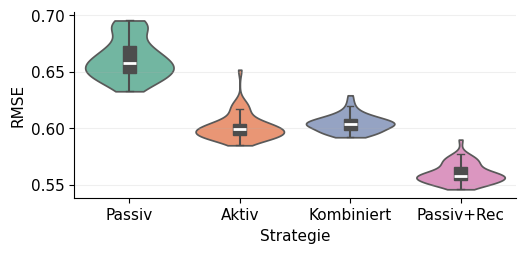

In [19]:
# Robustheits-Plot: Violin + Box (RMSE-Verteilung je Strategie ueber alle Seeds).
# Verteilungsplot ueber den arbeitsweit einheitlichen Helfer ts.violin_box; Styling
# via fig_width wie im uebrigen Notebook. Baseline bleibt draussen (deterministisch)
# und steht im Titel. Sinnvoll ab ~50 Seeds (N_SEED_RUNS), damit die KDE traegt.
import pandas as pd
from src.utils import thesis_style as ts

ts.fig_width()
_order = ["blind", "informed", "combined", "blind_rec"]
_labels = {"blind": "Passiv", "informed": "Aktiv", "combined": "Kombiniert", "blind_rec": "Passiv+Rec"}
_seeds = list(seed_results)
_long = pd.DataFrame({
    "Strategie": np.repeat([_labels[s] for s in _order], len(_seeds)),
    "RMSE": np.concatenate([seed_rmse.loc[s, _seeds].to_numpy(float) for s in _order]),
})

fig, ax = plt.subplots(figsize=(ts.fig_width(0.85), ts.fig_width(0.42)))
ts.violin_box(_long, "Strategie", "RMSE", order=[_labels[s] for s in _order],
              palette=ts.SET2[:len(_order)], ax=ax)
ax.set_ylabel("RMSE"); ax.set_xlabel("Strategie")
fig.tight_layout()
if IS_FINAL:
    plot_store.save_figure(fig, "adaptation_seed_violin", adapt_cfg,
                           final=IS_FINAL, savefig_kwargs={"dpi": 300},
                           archive_kwargs={"dpi": 300})
plt.show()


## Ergebnisse speichern

In [20]:
from src.utils import results_export as rx

# Kennzahlen sind nun Seed-Mittel (Zelle 26) -> durchgaengig als Dezimalzahl, auch
# n_train/n_detect/n_reject. Mittelwert -> "strategies", Streuung ueber die Seeds
# -> "strategies_std".
_keys = [(k, k, "num") for k in ["rmse", "bias", "sigma", "corr_abs",
                                 "n_train", "n_detect", "n_reject", "n_recall", "rmse_improvement"]]

doc = (rx.ResultDoc()
   .integer("n_samples", N)
   .integer("step_seconds", STEP_S)
   .integer("n_seeds", len(seed_results))
   .set("detectors_screened", list(DETECTORS))
   .set("informed_detector", BEST_DETECTOR)
   # Vollstaendig statt nur rmse/n_train: die Gleichstandsregel ist sonst im
   # Text nicht belegbar. rmse_seeds traegt die Einzelwerte, p_vs_lead den
   # gepaarten t-Test gegen den Fuehrenden und rel_vs_lead den relativen
   # Abstand -- die beiden Bedingungen, aus denen die Regel entscheidet.
   .set("screening", {d: {"rmse": float(v["rmse"]),
                          "rmse_std": float(v["rmse_std"]),
                          "rmse_seeds": [float(x) for x in v["rmse_seeds"]],
                          "p_vs_lead": float(v["p_vs_lead"]),
                          "rel_vs_lead": float(v["rel_vs_lead"]),
                          "n_train": float(v["n_train"])}
                      for d, v in screening.items()})
   .set("config", ADAPT_CFG)
   .set("tuning", {
       "step_tune_seconds": int(STEP_TUNE_S),
       "n_trials": N_TRIALS,
       "weights": list(TUNE_WEIGHTS),
       "best_params": best_adapt_params,
   })
   .set("cooldown", {"tuned": True, "x_range": [0.0, 60.0], "t_stat_points": float(T_stat)})
   .set("applied_config", applied_cfg)
   .stats(stats_mean, _keys, into="strategies",     rows=[k for k, _ in PANELS])
   .stats(stats_std,  _keys, into="strategies_std", rows=[k for k, _ in PANELS]))

if "seed_rmse" in dir():
    doc.set("seed_eval", {
        "seeds": [int(s) for s in SEEDS],
        "rmse": {s: {"mean": float(seed_rmse.loc[s, "mean"]),
                     "std": float(seed_rmse.loc[s, "std"])} for s in STRATEGIES},
    })

doc.save(res_store, "adaptation", adapt_cfg, final=IS_FINAL)

Umfassende Ergebnisse -> /work/results/syn_adaptation.json


'/work/results/syn_adaptation.json'

In [21]:
from src.utils import latex_export as lx

mx = lx.MacroExport("Automatisch erzeugt aus syn_adaptation.ipynb - nicht manuell editieren")

mx.comment("Parameter (Hash-relevant)")
mx.param("paramTa",     STEP_S,      unit=r"\second")
mx.param("paramTaTune", STEP_TUNE_S, unit=r"\second")
mx.param("paramNPoints", N)
mx.param("paramChunk",   CHUNK)
mx.param("paramNScreenSeeds", len(SCREENING_SEEDS), spell_out=True)

mx.comment("Detektor-Screening (Gleichstandsregel)")
# Anzeigenamen der Detektoren fuer den Fliesstext. Der Schwellwert-Detektor hat
# kein eigenes Akronym, die uebrigen werden ueber \ac{...} gesetzt.
_DET_LABEL = {"RMSE": "Schwellwert-Detektor", "DDM": r"\ac{DDM}",
              "EDDM": r"\ac{EDDM}", "ADWIN": r"\ac{ADWIN}", "KSWIN": r"\ac{KSWIN}"}
mx.num("paramTieAlpha", TIE_ALPHA, 2)
# Zweite Bedingung der Regel: hoechstens TIE_MAX_REL ueber dem Fuehrenden.
mx.num("paramTieMaxRel", 100 * TIE_MAX_REL, 0)
mx.raw("paramTieOrder", ", ".join(_DET_LABEL[d] for d in TIE_ORDER))
mx.raw("adaptScreenLead", _DET_LABEL[SCREEN_LEAD])
mx.raw("adaptDetector",   _DET_LABEL[BEST_DETECTOR])

mx.comment("Ergebnisse (Adaptionskennzahlen je Strategie; Mittelwert und Std ueber alle Seeds)")
mx.integer("adaptNSeeds", len(seed_results))
_name_map = {"baseline": "Baseline", "blind": "Blind", "blind_chunk": "BlindChunk",
             "informed": "Informed", "combined": "Combined", "blind_rec": "BlindRec"}
# (Spalte, Suffix, Nachkommastellen). Nachtrainings/Detektionen sind als Seed-Mittel
# nicht mehr ganzzahlig und werden daher mit einer Nachkommastelle ausgegeben. Zu
# jeder Kennzahl wird zusaetzlich die Streuung ueber die Seeds als ...Std-Makro
# erzeugt (fuer die "Mittelwert +/- Std"-Darstellung in der Tabelle).
_keys = [("rmse", "Rmse", 3), ("bias", "Bias", 3), ("sigma", "Sigma", 3),
         ("corr_abs", "CorrAbs", 2), ("rmse_improvement", "Improve", 3),
         ("n_train", "NTrain", 1), ("n_detect", "NDetect", 1), ("n_recall", "NRecall", 1)]
for k, _ in PANELS:
    m = _name_map[k]
    for col, suf, nd in _keys:
        mx.num(f"adapt{m}{suf}",    stats_mean.loc[k, col], nd)
        mx.num(f"adapt{m}{suf}Std", stats_std.loc[k, col],  nd)
    mx.num(f"adapt{_name_map[k]}RmseMin", seed_rmse.loc[k, list(seed_results)].min(), 3)

mx.save(res_store, "adaptation", adapt_cfg, final=IS_FINAL)

LaTeX-Makros -> /work/results/syn_adaptation.tex

% Automatisch erzeugt aus syn_adaptation.ipynb - nicht manuell editieren

% Parameter (Hash-relevant)
\newcommand{\paramTa}{\SI{600}{\second}}
\newcommand{\paramTaTune}{\SI{3600}{\second}}
\newcommand{\paramNPoints}{52560}
\newcommand{\paramChunk}{144}
\newcommand{\paramNScreenSeeds}{fünf}

% Detektor-Screening (Gleichstandsregel)
\newcommand{\paramTieAlpha}{0{,}05}
\newcommand{\paramTieMaxRel}{5}
\newcommand{\paramTieOrder}{Schwellwert-Detektor, \ac{DDM}, \ac{EDDM}, \ac{ADWIN}, \ac{KSWIN}}
\newcommand{\adaptScreenLead}{Schwellwert-Detektor}
\newcommand{\adaptDetector}{Schwellwert-Detektor}

% Ergebnisse (Adaptionskennzahlen je Strategie; Mittelwert und Std ueber alle Seeds)
\newcommand{\adaptNSeeds}{50}
\newcommand{\adaptBaselineRmse}{1{,}663}
\newcommand{\adaptBaselineRmseStd}{0{,}000}
\newcommand{\adaptBaselineBias}{0{,}401}
\newcommand{\adaptBaselineBiasStd}{0{,}000}
\newcommand{\adaptBaselineSigma}{1{,}614}
\newcommand{\adaptBaseli

'/work/results/syn_adaptation.tex'